<a href="https://colab.research.google.com/github/levmert/LLM-Agents/blob/main/V2_0_%5BWeek_1_LLM_Fundamentals%5D_LLM_%26_Agents_Bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM & Agents Bootcamp
# Week 1: LLM Fundamentals - How Language Models Work

# Understanding the Magic: From Text to Intelligence

Welcome to Week 1 of our workshop into LLMs and Agents. Before we go all-in into doing cool things with Agents, I want to make sure we understand the fundamentals of LLMs.

Understanding these fundamentals will be helpful to:
- gain a deeper understanding of what LLMs/Agents really are
- have more context when building with them, specifically their strengths and limitations
- cover core concepts frequently expected to be understood in ML/AI interviews

This class, we'll uncover how Large Language Models transform simple text into seemingly intelligent responses. We'll explore the four fundamental building blocks that make this magic possible.

## What You'll Learn Today:
1. **Tokenization**: How models "see" text
2. **Embeddings**: How words become mathematics  
3. **Attention**: How models understand context
4. **Generation**: How models create new text

Sources/Credit:
- https://github.com/HandsOnLLM/Hands-On-Large-Language-Models

## Required Setup

In [1]:
# Install required packages
!pip install transformers torch numpy matplotlib seaborn scikit-learn sentence-transformers gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.6 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, pipeline
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Tokenization: How LLMs "See" Text

Before we dive in, let's understand a fundamental truth: **LLMs don't see words like we do.** They see tokens - pieces of text that might be words, parts of words, or even individual characters.

## The Token Discovery Game
Let's play a game - guess how different models will tokenize various inputs:

In [ ]:
entire_english_language [cat, dog, train, plane, he, she]

cat = [1 0 0 0 0 0]
dog = [0 0 1 0 0 0......]

In [ ]:
# Load different tokenizers to compare
tokenizers = {
    "GPT-2": AutoTokenizer.from_pretrained("gpt2"),
    "BERT": AutoTokenizer.from_pretrained("bert-base-uncased"),
    "T5": AutoTokenizer.from_pretrained("t5-small")
}

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [ ]:
tokenizers['GPT-2'].tokenize("Compare how different tokenizers handle the same text...... $$$")

['Compare',
 'Ġhow',
 'Ġdifferent',
 'Ġtoken',
 'izers',
 'Ġhandle',
 'Ġthe',
 'Ġsame',
 'Ġtext',
 '......',
 'Ġ$',
 '$$']

In [ ]:
def tokenize_and_compare(text, tokenizers):
    """Compare how different tokenizers handle the same text"""
    print(f"🔍 Tokenizing: '{text}'")
    print("-" * 50)

    for name, tokenizer in tokenizers.items():
        tokens = tokenizer.tokenize(text)
        token_ids = tokenizer.encode(text)

        print(f"{name:8} | Tokens: {tokens}")
        print(f"{'':8} | Count: {len(tokens)} tokens")
        print(f"{'':8} | IDs: {token_ids[:10]}{'...' if len(token_ids) > 10 else ''}")
        print()

# Test cases that reveal interesting tokenization patterns
test_cases = [
    "Hello world!",
    "supercalifragilisticexpialidocious",
    "COVID-19 and GPT-4"
]

for test in test_cases:
    tokenize_and_compare(test, tokenizers)
    print("=" * 60)

🔍 Tokenizing: 'Hello world!'
--------------------------------------------------
GPT-2    | Tokens: ['Hello', 'Ġworld', '!']
         | Count: 3 tokens
         | IDs: [15496, 995, 0]

BERT     | Tokens: ['hello', 'world', '!']
         | Count: 3 tokens
         | IDs: [101, 7592, 2088, 999, 102]

T5       | Tokens: ['▁Hello', '▁world', '!']
         | Count: 3 tokens
         | IDs: [8774, 296, 55, 1]

🔍 Tokenizing: 'supercalifragilisticexpialidocious'
--------------------------------------------------
GPT-2    | Tokens: ['super', 'cal', 'if', 'rag', 'il', 'ist', 'ice', 'xp', 'ial', 'id', 'ocious']
         | Count: 11 tokens
         | IDs: [16668, 9948, 361, 22562, 346, 396, 501, 42372, 498, 312]...

BERT     | Tokens: ['super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious']
         | Count: 11 tokens
         | IDs: [101, 3565, 9289, 10128, 29181, 24411, 4588, 10288, 19312, 21273]...

T5       | Tokens: ['▁super', 'cali', 'frag', 'il', 'is

In [ ]:
# Try your own text and see how it gets tokenized
def explore_tokenization(text, model_name="gpt2"):
    """Interactive tokenization explorer"""
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Get tokens and IDs
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text)

    print(f"📝 Original text: '{text}'")
    print(f"🔢 Number of tokens: {len(tokens)}")
    print(f"📊 Tokens per word: {len(tokens) / len(text.split()):.2f}")
    print()

    # Show token-by-token breakdown
    print("Token Breakdown:")
    for i, (token, token_id) in enumerate(zip(tokens, token_ids)):
        # Decode individual token to see what it represents
        decoded = tokenizer.decode([token_id])
        print(f"  {i+1:2d}. '{token}' → ID: {token_id} → Decoded: '{decoded}'")

# Try it out!
explore_tokenization("The quick brown fox jumps over the lazy dog")


📝 Original text: 'The quick brown fox jumps over the lazy dog'
🔢 Number of tokens: 9
📊 Tokens per word: 1.00

Token Breakdown:
   1. 'The' → ID: 464 → Decoded: 'The'
   2. 'Ġquick' → ID: 2068 → Decoded: ' quick'
   3. 'Ġbrown' → ID: 7586 → Decoded: ' brown'
   4. 'Ġfox' → ID: 21831 → Decoded: ' fox'
   5. 'Ġjumps' → ID: 18045 → Decoded: ' jumps'
   6. 'Ġover' → ID: 625 → Decoded: ' over'
   7. 'Ġthe' → ID: 262 → Decoded: ' the'
   8. 'Ġlazy' → ID: 16931 → Decoded: ' lazy'
   9. 'Ġdog' → ID: 3290 → Decoded: ' dog'


In [ ]:
input = "The quick brown fox jumps over the lazy " # to the LLM
# computation to compite the llm output is N^2
# if N represetns characters, then

In [ ]:
len(input)

40

In [ ]:
1600 (char-level tokeniztion) vs 64 (byte level tokenzation)

In [ ]:
['a', b, c, d, 0, 1, 2, 3, 4, $, ' ']

In [ ]:
"the dog"
['the', ' ', 'dog']

' '

In [ ]:
[20,000 zeros, 1, 50,000 zeros]

In [ ]:
# view tokenizer vocab size
tokenizers['GPT-2'].vocab_size

50257

# 2. Embeddings: The Mathematics of Meaning

Now comes the real magic! How do we turn these tokens into numbers that capture meaning? Enter **embeddings** - the bridge between human language and machine understanding.

## The Embedding Space Theater
Think of embeddings as a vast theater where every word has a specific seat. Similar words sit close together, while different words are far apart.


In [ ]:
# Load a sentence transformer for high-quality embeddings
embedding_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# get embedding dim
embedding_model.get_sentence_embedding_dimension()

768

In [ ]:
"king", "queen", "man", "woman"

In [ ]:
"male" + "monarch" = "king"

"king" - "royalty" = "some representation of the idea of 'male'"



In [ ]:
# food
apple = [0.2, 0.5, 0.5, 1]

# company
apple = [0.2, 0.5, 0.5, 0]

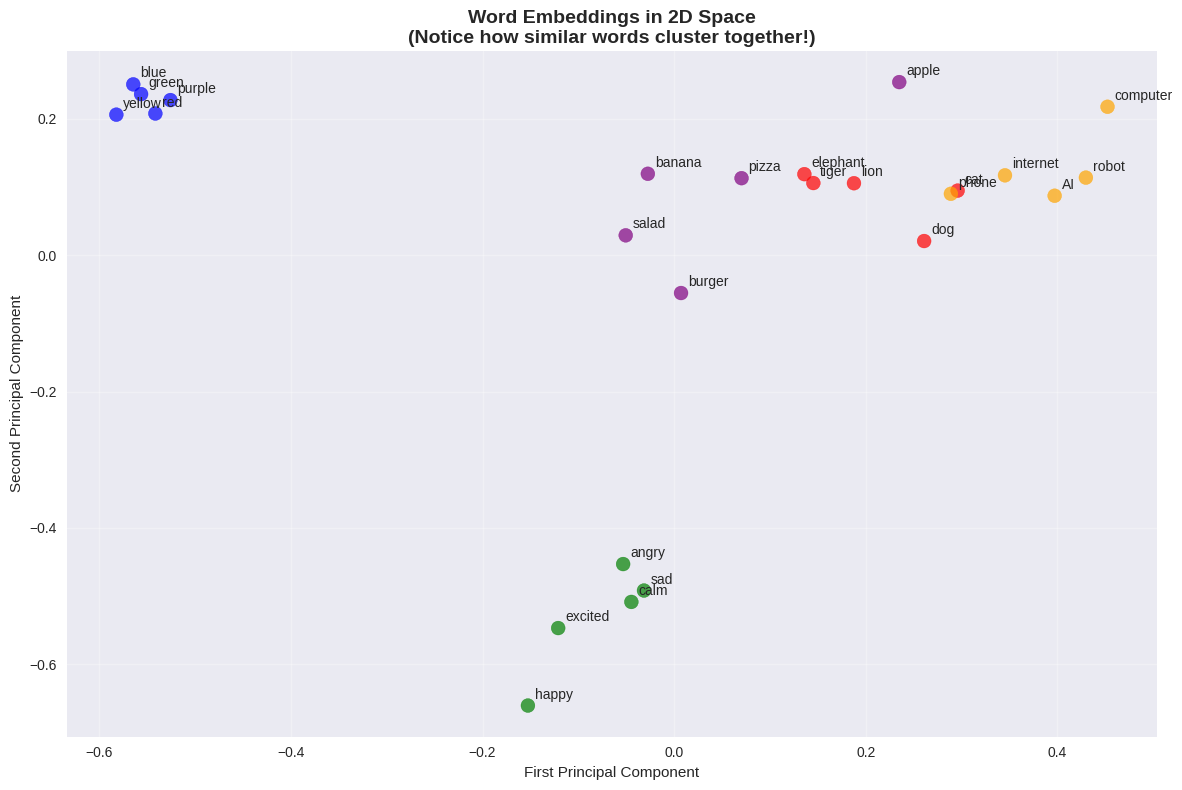

In [ ]:
def visualize_word_relationships():
    """Visualize how embeddings capture word relationships"""

    # Interesting word groups to explore
    words = [
        # Animals
        "cat", "dog", "lion", "tiger", "elephant",
        # Colors
        "red", "blue", "green", "yellow", "purple",
        # Emotions
        "happy", "sad", "angry", "excited", "calm",
        # Technology
        "computer", "phone", "internet", "AI", "robot",
        # Food
        "apple", "banana", "pizza", "burger", "salad"
    ]

    # Get embeddings
    embeddings = embedding_model.encode(words)

    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    # Create color map by category
    colors = ['red'] * 5 + ['blue'] * 5 + ['green'] * 5 + ['orange'] * 5 + ['purple'] * 5

    # Plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=colors, s=100, alpha=0.7)

    # Add labels
    for i, word in enumerate(words):
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    xytext=(5, 5), textcoords='offset points', fontsize=10)

    plt.title("Word Embeddings in 2D Space\n(Notice how similar words cluster together!)",
              fontsize=14, fontweight='bold')
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_word_relationships()


## The Famous Word2Vec Analogies
Let's recreate the famous "king - man + woman = queen" analogy that made word embeddings famous!


In [ ]:
def demonstrate_word_analogies():
    """Show famous word embedding analogies"""

    # Famous analogy examples
    analogies = [
        ("king", "man", "woman", "queen"),
        ("Paris", "France", "Italy", "Rome"),
        ("good", "better", "bad", "worse"),
        ("walking", "walked", "running", "ran")
    ]

    # Expanded vocabulary for better results
    vocabulary = [
        # People/Royalty
        "queen", "king", "prince", "princess", "emperor", "empress",
        "man", "woman", "boy", "girl", "male", "female",

        # Places
        "Rome", "Paris", "London", "Berlin", "Madrid", "Vienna",
        "France", "Italy", "Germany", "Spain", "England", "Austria",

        # Adjectives/Comparatives
        "good", "better", "best", "bad", "worse", "worst",
        "big", "bigger", "biggest", "small", "smaller", "smallest",

        # Verbs/Tenses
        "walk", "walking", "walked", "run", "running", "ran",
        "eat", "eating", "ate", "drink", "drinking", "drank",
        "sing", "singing", "sang", "dance", "dancing", "danced"
    ]

    # Get all embeddings at once for efficiency
    vocab_embeddings = embedding_model.encode(vocabulary)

    for a, b, c, expected in analogies:
        print(f"🧮 Analogy: {a} - {b} + {c} = ?")
        print(f"   Expected: {expected}")

        # Get embeddings for analogy words
        emb_a = embedding_model.encode([a])
        emb_b = embedding_model.encode([b])
        emb_c = embedding_model.encode([c])

        # Calculate analogy vector: a - b + c
        analogy_vector = emb_a - emb_b + emb_c

        # Calculate similarities with vocabulary
        similarities = cosine_similarity(analogy_vector, vocab_embeddings)[0]

        # Create a list of (word, similarity) pairs, excluding input words
        input_words = {a.lower(), b.lower(), c.lower()}
        candidates = [
            (word, sim) for word, sim in zip(vocabulary, similarities)
            if word.lower() not in input_words
        ]

        # Sort by similarity (descending)
        candidates.sort(key=lambda x: x[1], reverse=True)

        # Get top 3 results
        print("   Top 3 candidates:")
        for i, (word, sim) in enumerate(candidates[:3]):
            marker = "✅" if word.lower() == expected.lower() else "  "
            print(f"   {i+1}. {word} (similarity: {sim:.3f}) {marker}")

        best_match = candidates[0][0]
        print(f"   {'✅ Correct!' if best_match.lower() == expected.lower() else '❌ Not quite...'}")
        print()

demonstrate_word_analogies()

🧮 Analogy: king - man + woman = ?
   Expected: queen
   Top 3 candidates:
   1. queen (similarity: 0.509) ✅
   2. princess (similarity: 0.477)   
   3. empress (similarity: 0.459)   
   ✅ Correct!

🧮 Analogy: Paris - France + Italy = ?
   Expected: Rome
   Top 3 candidates:
   1. Rome (similarity: 0.665) ✅
   2. London (similarity: 0.586)   
   3. Berlin (similarity: 0.560)   
   ✅ Correct!

🧮 Analogy: good - better + bad = ?
   Expected: worse
   Top 3 candidates:
   1. worst (similarity: 0.282)   
   2. big (similarity: 0.253)   
   3. drank (similarity: 0.235)   
   ❌ Not quite...

🧮 Analogy: walking - walked + running = ?
   Expected: ran
   Top 3 candidates:
   1. run (similarity: 0.557)   
   2. drinking (similarity: 0.544)   
   3. dancing (similarity: 0.537)   
   ❌ Not quite...



## Contextualized Embeddings: The Same Word, Different Meanings
Static embeddings (like Word2Vec) give the same vector for "bank" whether it's a river bank or a financial institution. Modern models create contextual embeddings that change based on context!


In [ ]:
def explore_contextual_embeddings():
    """Show how context changes embeddings"""

    # Load a contextual model (BERT)
    model_name = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    # Test sentences with ambiguous words
    sentences = [
        "I went to the bank to deposit money",
        "We sat by the river bank and watched the sunset",
        "The bat flew out of the cave",
        "He swung the bat and hit a home run"
    ]

    target_words = ["bank", "bank", "bat", "bat"]

    print("🔄 Contextual Embeddings Demo")
    print("=" * 40)

    embeddings = []

    for sent, target in zip(sentences, target_words):
        # Tokenize
        inputs = tokenizer(sent, return_tensors='pt')

        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            hidden_states = outputs.last_hidden_state

        # Find target word position
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        target_pos = None
        for i, token in enumerate(tokens):
            if target in token:
                target_pos = i
                break

        if target_pos is not None:
            word_embedding = hidden_states[0, target_pos, :].numpy()
            embeddings.append(word_embedding)
            print(f"'{sent}'")
            print(f"  → '{target}' embedding shape: {word_embedding.shape}")
        print()

    # Calculate similarity between same words in different contexts
    if len(embeddings) >= 2:
        sim_banks = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
        sim_bats = cosine_similarity([embeddings[2]], [embeddings[3]])[0][0]

        print(f"📊 Similarity between 'bank' contexts: {sim_banks:.3f}")
        print(f"📊 Similarity between 'bat' contexts: {sim_bats:.3f}")
        print("💡 Lower similarity = model understands different meanings!")

explore_contextual_embeddings()


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

🔄 Contextual Embeddings Demo
'I went to the bank to deposit money'
  → 'bank' embedding shape: (768,)

'We sat by the river bank and watched the sunset'
  → 'bank' embedding shape: (768,)

'The bat flew out of the cave'
  → 'bat' embedding shape: (768,)

'He swung the bat and hit a home run'
  → 'bat' embedding shape: (768,)

📊 Similarity between 'bank' contexts: 0.508
📊 Similarity between 'bat' contexts: 0.459
💡 Lower similarity = model understands different meanings!


In [ ]:
# Load a contextual model (BERT)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Test sentences with ambiguous words
sentences = [
    "I went to the bank to deposit money",
    "We sat by the river bank and watched the sunset",
    "The bat flew out of the cave",
    "He swung the bat and hit a home run"
]

target_words = ["bank", "bank", "bat", "bat"]

print("🔄 Contextual Embeddings Demo")
print("=" * 40)

embeddings = []

for sent, target in zip(sentences, target_words):
    # Tokenize
    inputs = tokenizer(sent, return_tensors='pt')

    # Get embeddings
    with torch.no_grad():
        outputs = model(**inputs)
        hidden_states = outputs.last_hidden_state

    # Find target word position
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    target_pos = None
    for i, token in enumerate(tokens):
        if target in token:
            target_pos = i
            break

    if target_pos is not None:
        word_embedding = hidden_states[0, target_pos, :].numpy()
        embeddings.append(word_embedding)
        print(f"'{sent}'")
        print(f"  → '{target}' embedding shape: {word_embedding.shape}")
    print()

# Calculate similarity between same words in different contexts
if len(embeddings) >= 2:
    sim_banks = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    sim_bats = cosine_similarity([embeddings[2]], [embeddings[3]])[0][0]

    print(f"📊 Similarity between 'bank' contexts: {sim_banks:.3f}")
    print(f"📊 Similarity between 'bat' contexts: {sim_bats:.3f}")
    print("💡 Lower similarity = model understands different meanings!")


# 3. Attention: The Art of Focus

Attention is what makes transformers truly special. It allows models to focus on relevant parts of the input when processing each word. Let's visualize this superpower!

## Attention Visualization

In [ ]:
my_list = "I went to the bank to deposit money".split()
my_list

['I', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money']

In [ ]:
for i, w_i in enumerate(my_list):
  for j, w_j in enumerate(my_list):
      print("Word doing the attending", i, w_i)
      print("Word being attended to", i, j)

Word doing the attending 0 I
Word being attended to 0 0
Word doing the attending 0 I
Word being attended to 0 1
Word doing the attending 0 I
Word being attended to 0 2
Word doing the attending 0 I
Word being attended to 0 3
Word doing the attending 0 I
Word being attended to 0 4
Word doing the attending 0 I
Word being attended to 0 5
Word doing the attending 0 I
Word being attended to 0 6
Word doing the attending 0 I
Word being attended to 0 7
Word doing the attending 1 went
Word being attended to 1 0
Word doing the attending 1 went
Word being attended to 1 1
Word doing the attending 1 went
Word being attended to 1 2
Word doing the attending 1 went
Word being attended to 1 3
Word doing the attending 1 went
Word being attended to 1 4
Word doing the attending 1 went
Word being attended to 1 5
Word doing the attending 1 went
Word being attended to 1 6
Word doing the attending 1 went
Word being attended to 1 7
Word doing the attending 2 to
Word being attended to 2 0
Word doing the attendin

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


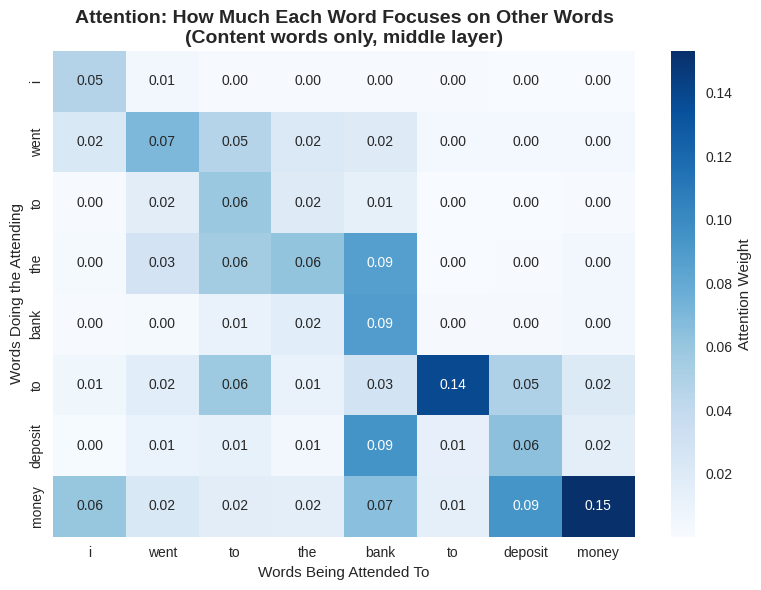

🔍 What each word focuses on most:
  'i' → 'i' (0.05)
  'went' → 'went' (0.07)
  'to' → 'to' (0.06)
  'the' → 'bank' (0.09)
  'bank' → 'bank' (0.09)
  'to' → 'to' (0.14)
  'deposit' → 'bank' (0.09)
  'money' → 'money' (0.15)

🧠 What This Shows:
- Each cell shows how much one word 'pays attention' to another
- Darker blue = more attention
- This helps words understand their meaning based on context

💡 Key Insight:
This is how transformers figure out relationships between words!


In [ ]:
def visualize_attention_simple():
    """Simple attention visualization to show the main concept"""

    # Load model
    model_name = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_attentions=True)

    # Simple, clear sentence
    text = "I went to the bank to deposit money"

    # Get tokens and attention
    inputs = tokenizer(text, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    with torch.no_grad():
        outputs = model(**inputs)
        attentions = outputs.attentions

    # Try different layers and heads to find meaningful patterns
    # Middle layers often show more interpretable patterns
    layer_idx = len(attentions) // 2  # Middle layer

    # Remove special tokens for cleaner visualization
    content_tokens = [t for t in tokens if t not in ['[CLS]', '[SEP]']]
    start_idx = 1  # Skip [CLS]
    end_idx = len(tokens) - 1  # Skip [SEP]

    # Get attention weights for content words only
    attention_matrix = attentions[layer_idx][0, 0, start_idx:end_idx, start_idx:end_idx].numpy()

    # Create simple heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(attention_matrix,
                xticklabels=content_tokens,
                yticklabels=content_tokens,
                cmap='Blues',
                annot=True,
                fmt='.2f',
                cbar_kws={'label': 'Attention Weight'})

    plt.title("Attention: How Much Each Word Focuses on Other Words\n(Content words only, middle layer)",
              fontsize=14, fontweight='bold')
    plt.xlabel("Words Being Attended To")
    plt.ylabel("Words Doing the Attending")
    plt.tight_layout()
    plt.show()

    # Show what different words pay attention to
    print("🔍 What each word focuses on most:")
    for i, word in enumerate(content_tokens):
        attention_row = attention_matrix[i]
        max_attention_idx = np.argmax(attention_row)
        max_attention_word = content_tokens[max_attention_idx]
        max_attention_value = attention_row[max_attention_idx]
        print(f"  '{word}' → '{max_attention_word}' ({max_attention_value:.2f})")

    # Simple explanation
    print("\n🧠 What This Shows:")
    print("- Each cell shows how much one word 'pays attention' to another")
    print("- Darker blue = more attention")
    print("- This helps words understand their meaning based on context")
    print("\n💡 Key Insight:")
    print("This is how transformers figure out relationships between words!")

visualize_attention_simple()

In [ ]:
# TODO: investigation on our own time: Attention mechanism in details: Q, K, V

# 4. Text Generation: From Probabilities to Prose

Now let's see how models generate text! It's not magic - it's a carefully orchestrated process of predicting one token at a time.

## The Generation Process

In [ ]:
# Load a generative model
model_name = "microsoft/DialoGPT-medium"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Set pad token
tokenizer.pad_token = tokenizer.eos_token


tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
# Starting prompt
prompt = "The city that is the capital of France is"

print(f"🚀 Starting with: '{prompt}'")
print("=" * 50)

# Tokenize initial prompt
input_ids = tokenizer.encode(prompt, return_tensors='pt')
generated_text = prompt

🚀 Starting with: 'The city that is the capital of France is'


In [ ]:
input_ids

tensor([[ 464, 1748,  326,  318,  262, 3139,  286, 4881,  318]])

In [ ]:
# Get model predictions
with torch.no_grad():
    outputs = model(input_ids)
    logits = outputs.logits[0, -1, :]

In [ ]:
# get the tokenizer dimension
model.config.vocab_size

50257

In [ ]:
tokenizer.vocab_size

50257

In [ ]:
probs = F.softmax(logits, dim=-1)

In [ ]:
len(probs)

50257

In [ ]:
probs

tensor([1.0018e-06, 4.7624e-11, 5.9423e-11,  ..., 3.7742e-09, 8.5407e-08,
        9.7391e-04])

In [ ]:
probs.shape

torch.Size([50257])

In [ ]:
# get the most likely token and the associated word it represents
probs.argmax()

tokenizer.decode(probs.argmax())

' Paris'

In [ ]:
probs.shape

torch.Size([50257])

In [ ]:
probs.max()

tensor(0.1389)

In [ ]:
top_k = 10
top_probs, top_indices = torch.topk(probs, top_k)

In [ ]:
top_probs, top_indices

(tensor([0.1389, 0.0850, 0.0408, 0.0391, 0.0357, 0.0204, 0.0154, 0.0130, 0.0127,
         0.0124]),
 tensor([ 6342,   262,   287,  1444,   407,   257,   635,  3706,  4881, 18460]))

In [ ]:
prompt = "The city that is the capital of France is"


In [ ]:
print("Top predictions:")
for i, (prob, idx) in enumerate(zip(top_probs, top_indices)):
    token = tokenizer.decode([idx])
    print(f"  {i+1:2d}. '{token}' (prob: {prob:.3f})")

Top predictions:
   1. ' Paris' (prob: 0.139)
   2. ' the' (prob: 0.085)
   3. ' in' (prob: 0.041)
   4. ' called' (prob: 0.039)
   5. ' not' (prob: 0.036)
   6. ' a' (prob: 0.020)
   7. ' also' (prob: 0.015)
   8. ' named' (prob: 0.013)
   9. ' France' (prob: 0.013)
  10. ' Nice' (prob: 0.012)


In [ ]:
# Generate 5 tokens step by step
for step in range(5):
    print(f"\n📍 Step {step + 1}:")
    print(f"Current text: '{generated_text}'")

    # Get model predictions
    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[0, -1, :]  # Last token predictions

    # Convert to probabilities
    probs = F.softmax(logits, dim=-1)

    # Get top 10 predictions
    top_k = 10
    top_probs, top_indices = torch.topk(probs, top_k)

    print("Top predictions:")
    for i, (prob, idx) in enumerate(zip(top_probs, top_indices)):
        token = tokenizer.decode([idx])
        print(f"  {i+1:2d}. '{token}' (prob: {prob:.3f})")

    # Choose next token (greedy for now)
    next_token_id = top_indices[0]
    next_token = tokenizer.decode([next_token_id])

    print(f"✅ Chosen: '{next_token}'")

    # Update for next iteration
    input_ids = torch.cat([input_ids, next_token_id.unsqueeze(0).unsqueeze(0)], dim=1)
    generated_text += next_token

print(f"\n🎉 Final result: '{generated_text}'")


📍 Step 1:
Current text: 'The city that is the capital of France is '
Top predictions:
   1. 'ich' (prob: 0.096)
   2. 'ile' (prob: 0.068)
   3. 'ix' (prob: 0.066)
   4. 'iz' (prob: 0.062)
   5. 'izz' (prob: 0.045)
   6. 'irl' (prob: 0.042)
   7. 'irc' (prob: 0.033)
   8. 'urs' (prob: 0.031)
   9. 'ike' (prob: 0.031)
  10. 'igg' (prob: 0.027)
✅ Chosen: 'ich'

📍 Step 2:
Current text: 'The city that is the capital of France is ich'
Top predictions:
   1. ' bin' (prob: 0.090)
   2. 'igan' (prob: 0.062)
   3. 'igo' (prob: 0.042)
   4. 'thy' (prob: 0.027)
   5. 'ig' (prob: 0.025)
   6. '.' (prob: 0.025)
   7. 'ab' (prob: 0.020)
   8. 'ib' (prob: 0.018)
   9. 'ih' (prob: 0.013)
  10. 'a' (prob: 0.011)
✅ Chosen: ' bin'

📍 Step 3:
Current text: 'The city that is the capital of France is ich bin'
Top predictions:
   1. ' e' (prob: 0.382)
   2. ' der' (prob: 0.055)
   3. ' d' (prob: 0.033)
   4. ' de' (prob: 0.028)
   5. ' f' (prob: 0.012)
   6. ' Berlin' (prob: 0.008)
   7. ' mir' (prob: 0.008)

In [ ]:
def demonstrate_generation_process():
    """Show step-by-step text generation"""

    # Load a generative model
    model_name = "microsoft/DialoGPT-medium"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    # Set pad token
    tokenizer.pad_token = tokenizer.eos_token

    # Starting prompt
    prompt = "The city that is the capital of France is "

    print(f"🚀 Starting with: '{prompt}'")
    print("=" * 50)

    # Tokenize initial prompt
    input_ids = tokenizer.encode(prompt, return_tensors='pt')
    generated_text = prompt

    # Generate 5 tokens step by step
    for step in range(5):
        print(f"\n📍 Step {step + 1}:")
        print(f"Current text: '{generated_text}'")

        # Get model predictions
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits[0, -1, :]  # Last token predictions

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Get top 10 predictions
        top_k = 10
        top_probs, top_indices = torch.topk(probs, top_k)

        print("Top predictions:")
        for i, (prob, idx) in enumerate(zip(top_probs, top_indices)):
            token = tokenizer.decode([idx])
            print(f"  {i+1:2d}. '{token}' (prob: {prob:.3f})")

        # Choose next token (greedy for now)
        next_token_id = top_indices[0]
        next_token = tokenizer.decode([next_token_id])

        print(f"✅ Chosen: '{next_token}'")

        # Update for next iteration
        input_ids = torch.cat([input_ids, next_token_id.unsqueeze(0).unsqueeze(0)], dim=1)
        generated_text += next_token

    print(f"\n🎉 Final result: '{generated_text}'")

demonstrate_generation_process()


tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

🚀 Starting with: 'The city which is the capital of France is'

📍 Step 1:
Current text: 'The city which is the capital of France is'
Top predictions:
   1. ' Paris' (prob: 0.099)
   2. ' the' (prob: 0.086)
   3. ' called' (prob: 0.065)
   4. ' in' (prob: 0.047)
   5. ' not' (prob: 0.037)
   6. ' named' (prob: 0.026)
   7. ' also' (prob: 0.023)
   8. ' a' (prob: 0.019)
   9. ' France' (prob: 0.013)
  10. ' located' (prob: 0.011)
✅ Chosen: ' Paris'

📍 Step 2:
Current text: 'The city which is the capital of France is Paris'
Top predictions:
   1. '.' (prob: 0.450)
   2. ',' (prob: 0.251)
   3. '<|endoftext|>' (prob: 0.132)
   4. '!' (prob: 0.025)
   5. ' and' (prob: 0.022)
   6. '?' (prob: 0.015)
   7. '...' (prob: 0.013)
   8. ' in' (prob: 0.004)
   9. ' or' (prob: 0.003)
  10. ' for' (prob: 0.002)
✅ Chosen: '.'

📍 Step 3:
Current text: 'The city which is the capital of France is Paris.'
Top predictions:
   1. '<|endoftext|>' (prob: 0.369)
   2. ' Paris' (prob: 0.121)
   3. ' The' (prob: 

## Sampling Strategies: Creativity vs Coherence
Different sampling methods produce different styles of text. Let's explore!


In [ ]:
def compare_sampling_strategies():
    """Compare different text generation strategies - educational demo"""

    # Use Qwen2.5-0.5B - recent, small, smart model
    model_name = "Qwen/Qwen2.5-0.5B"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    prompt = "The robot walked into the room and"

    strategies = [
        {"name": "Greedy", "do_sample": False},
        {"name": "Temperature=0.3", "do_sample": True, "temperature": 0.3},
        {"name": "Temperature=1.0", "do_sample": True, "temperature": 1.0},
        {"name": "Top-k=10", "do_sample": True, "top_k": 10},
        {"name": "Top-p=0.8", "do_sample": True, "top_p": 0.8},
    ]

    print(f"🎭 Sampling strategies demo: '{prompt}'")
    print("=" * 50)

    for strategy in strategies:
        inputs = tokenizer(prompt, return_tensors='pt')

        with torch.no_grad():
            outputs = model.generate(
                inputs.input_ids,
                attention_mask=inputs.attention_mask,
                max_length=inputs.input_ids.shape[1] + 15,
                max_new_tokens=inputs.input_ids.shape[1] + 15,
                num_return_sequences=1,
                pad_token_id=tokenizer.eos_token_id,
                **{k: v for k, v in strategy.items() if k != 'name'}
            )

        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        print(f"\n🎲 {strategy['name']}:")
        print(f"'{generated_text}'")

compare_sampling_strategies()

Both `max_new_tokens` (=22) and `max_length`(=22) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🎭 Sampling strategies demo: 'The robot walked into the room and'


Both `max_new_tokens` (=22) and `max_length`(=22) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🎲 Greedy:
'The robot walked into the room and sat down on the sofa. It was a sofa that had been sitting in the living room for years. It'


Both `max_new_tokens` (=22) and `max_length`(=22) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🎲 Temperature=0.3:
'The robot walked into the room and sat down on the sofa. It looked at the books on the table and then sat down next to the computer'


Both `max_new_tokens` (=22) and `max_length`(=22) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🎲 Temperature=1.0:
'The robot walked into the room and into the kitchen. "What are you doing?" asked Mr. Johnson. "We don't have a coffee'


Both `max_new_tokens` (=22) and `max_length`(=22) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🎲 Top-k=10:
'The robot walked into the room and saw his friend, Sam.  They had been friends since the day they met.  They had always been'

🎲 Top-p=0.8:
'The robot walked into the room and saw 6 books on the table. He started reading the first book, which has 20 pages.'


# Interactive Playground: Putting It All Together

Let's create a mini-playground where you can experiment with everything we've learned!


In [ ]:
def llm_playground():
    """Interactive playground for experimenting with LLM concepts"""

    print("🎮 LLM Playground - Try Different Experiments!")
    print("=" * 50)

    # Load models
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    model = AutoModelForCausalLM.from_pretrained("gpt2")
    embedding_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    tokenizer.pad_token = tokenizer.eos_token

    def experiment_1():
        """Token count predictor"""
        text = "Hello, wonderful world of artificial intelligence!"
        tokens = tokenizer.tokenize(text)
        print(f"🔢 Text: '{text}'")
        print(f"    Tokens: {len(tokens)} | {tokens}")

    def experiment_2():
        """Embedding similarity"""
        words = ["happy", "joyful", "sad", "computer"]
        embeddings = embedding_model.encode(words)
        similarity_matrix = cosine_similarity(embeddings)

        print("📊 Word Similarity Matrix:")
        for i, word1 in enumerate(words):
            for j, word2 in enumerate(words):
                if i != j:
                    sim = similarity_matrix[i][j]
                    print(f"    {word1} ↔ {word2}: {sim:.3f}")

    def experiment_3():
        """Quick generation"""
        prompt = "The secret to happiness is"
        input_ids = tokenizer.encode(prompt, return_tensors='pt')

        with torch.no_grad():
            outputs = model.generate(
                input_ids,
                max_length=input_ids.shape[1] + 15,
                temperature=0.8,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
        print(f"✨ Generated: '{generated}'")

    # Run experiments
    print("\n🧪 Experiment 1: Tokenization")
    experiment_1()

    print("\n🧪 Experiment 2: Embeddings")
    experiment_2()

    print("\n🧪 Experiment 3: Generation")
    experiment_3()

llm_playground()
